In [1]:
import uproot
import os
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
import pandas as pd
from matplotlib.patches import Patch
from scipy.stats import norm


Definimos Variables

In [2]:
#Carpeta donde están guardados todos los outputs de root (directorio de trabajo de python + rootArchives)
base_folder = './rootArchives/posterViena/'

#Carpeta donde están guardados todos los espectros de referencia en el secundario
spectra_folder = './Espectros/'



fit_parameters_wo_uncertainties_true = { 'f_CF3':0.09625, 'f_ar_exc*P2A1':0.2905, 'quenching_ratio_ar_ex':0.038,
                   'tau_1_K_cool':0.026,  'K_scint_tau_2':0.070, 'f_CF4':0.291,
                    'quenching_ratio_ar_ion':6.238, 'P_CD':0.671, 'tau3_cont':5,
}



fit_parameters_wo_uncertainties = { 'f_CF3':1, 'f_ar_exc*P2A1':1, 'quenching_ratio_ar_ex':0.038,
                   'tau_1_K_cool':0.026,  'K_scint_tau_2':0.070, 'f_CF4':0.291,
                    'quenching_ratio_ar_ion':6.238, 'P_CD':0.671, 'tau3_cont':5,
}


#Parámetros de referencia de los espectros de mezclas de CF4
pars_ref = {"mu_230": 236.13/ 236.13 * 230, "sigma_230": 11.19 * 1.1, "A_230": 4.77, "mu_260": 259.30, "sigma_260": 13.63 * 1.5, 
                    "mu_290": 289.00 / 289 * 295, "sigma_290": 20.90, "A_290": 5.64, "mu_400": 373.6, "sigma_400": 50.94, "A_400": 1.16,
                    "mu_620": 630.77, "sigma_620": 39.85 * 1.2}



Datos Ar_CF4

In [3]:
ar_cf4_experimental_concs = np.array([5, 10, 67, 100])
ar_cf4_experimental_phe_e_visir = np.array([0.575117370892018, 0.548826291079812, 0.300156494522691, 0.0926277372262773])
ar_cf4_experimental_phe_e_vis = np.array([0.38287151, 0.38966203, 0.2802068, 0.09335376])
ar_cf4_experimental_errors_vis = np.array([ 0.005477291487030911, 0.010954582974061933, 0.005478365465753865, 0.007668231611893575])
ar_cf4_systematical_errors_vis = 0.2 * ar_cf4_experimental_phe_e_visir
ar_cf4_total_errors_vis = np.sqrt(ar_cf4_experimental_errors_vis**2 + ar_cf4_systematical_errors_vis**2)
ar_cf4_experimental_concs_uv = np.array([5, 67, 100])
ar_cf4_experimental_phe_e_uv = np.array([0.06737771706391489,0.08455236611728804, 0.044033601820777875, 0.03942121448304051])
# ar_cf4_experimental_errors_uv = np.array([0.0006416905744254584, 0.0016876667997495743, 0.000803687969275206, 0.0032635041309454767])
# ar_cf4_systematical_errors_uv = 0.2 * ar_cf4_experimental_phe_e_uv
# ar_cf4_total_errors_uv = np.sqrt(ar_cf4_experimental_errors_uv**2 + ar_cf4_systematical_errors_uv**2)
ar_cf4_total_errors_uv = np.array([0.013490812870036886, 0.016994479521607656, 0.00884331537513073, 0.00859011077564899])

E_fields_ar_cf4 = {5:65, 10:78, 67:88, 100:95}

yields_cf4_100_25_mbar = {'vis':0.04953590534192422, 'uv':0.1367619130620444}
yields_arcf4_8020_50_mbar = {'vis':0.1057123306627957, 'uv':0.02769685258037305}
yields_arcf4_8020_1_bar = {'vis':0.3542058185498147, 'uv':0.04599727051007351 }


Datos He_CF4

In [4]:
he_cf4_experimental_concs = np.array([20, 40, 100])
he_cf4_experimental_phe_e_visir = np.array([0.0668231611893583, 0.0701095461658841, 0.0926277372262773])
he_cf4_experimental_phe_e_vis = np.array([0.05981728, 0.0633149, 0.09335376])
he_cf4_experimental_errors_vis = np.array([0.010954582974061822, 0.019718249353311457, 0.007668231611893575])
he_cf4_systematical_errors_vis = 0.2 * he_cf4_experimental_phe_e_vis
he_cf4_total_errors_vis = np.sqrt(he_cf4_systematical_errors_vis**2 + he_cf4_experimental_errors_vis**2)
he_cf4_experimental_phe_e_uv = np.array([0.0586689111317149, 0.12606696047521188, 0.03942121448304051])
he_cf4_experimental_errors_uv = np.array([0.009617824771399473, 0.03545622383551968, 0.0032635041309454767])
he_cf4_systematical_errors_uv = 0.2 * he_cf4_experimental_phe_e_uv
he_cf4_total_errors_uv = np.sqrt(he_cf4_systematical_errors_uv**2 + he_cf4_experimental_errors_uv**2)
he_cf4_total_errors_uv = np.array([0.014241770732051665, 0.04213797898747448, 0.00859011077564899])

E_fields_he_cf4 = {20: 60, 40:75, 100:95}


yields_hecf4_8020_300_mbar = {'vis':0.03459508998978698, 'uv':0.0709633243946791}


Definimos funciones

In [5]:
def open_root(P, gas_a, conc_a, conc_b, E_field, gap, npe, gas_b='cf4', **kwargs):

    P_str = f'{P:.3f}'.rstrip('0').rstrip('.')

    if conc_b == 100:
        root_path = base_folder + f'ar100.0{gas_b}_{E_field:.1f}kVcm_{P_str}bar_{gap:.2f}mm_{npe:d}npe.root'

    else:
        root_path = base_folder + f'{gas_a}{conc_b:.1f}{gas_b}_{E_field:.1f}kVcm_{P_str}bar_{gap:.2f}mm_{npe:d}npe.root'

    root_file = uproot.open(root_path)

    hLevels = root_file['hLevels'].values()

    return root_file, hLevels


In [6]:
def open_spectrum(P, gas_a, conc_b, origin, gas_b='CF4'):
    spectrum_path = spectra_folder + f'{gas_a}{gas_b}_{100 - conc_b}{conc_b:02d}_{P}_bar_{origin}.csv'

    spectrum_df = pd.read_csv(spectrum_path, delimiter=';', decimal=',', header=None)

    return spectrum_df

In [7]:
ratio_cf3_exc_uv_vis = 0.17394463
#ratio_cf3_exc_uv_vis = 0.190905093 /3


def ph_e(Pressure, gas_a, conc_a, conc_b, E_field, gap, npe, quench_ion, n_start_ar=0, n_start_he=0, n_start_cf4=0, gas_b='cf4', tope=False, include_cf3=True, **kwargs):

    root_file, hLevels = open_root(Pressure, gas_a, conc_a, conc_b, E_field, gap, npe, gas_b, **kwargs)


    n_e = sum(root_file['dataPerPrimaryElectron;1']['nElectrons'].array())
    n_i = sum(root_file['dataPerPrimaryElectron;1']['nIons'].array())

    n_exc_ar_vis, n_exc_he_vis, n_ion_ar_uv, n_ion_he_uv = 0, 0, 0, 0
    n_exc_vis, n_ion_uv, n_exc_dir_vis, n_ion_dir_uv = 0, 0, 0, 0

    if conc_b == 100:
            index_start_direct = 23 + n_start_cf4

            if tope:
                n_exc_dir_vis = sum(hLevels[index_start_direct : 44])
            else:
                n_exc_dir_vis = sum(hLevels[index_start_direct:])

            n_ion_dir_uv = hLevels[1] + hLevels[6] #Canal directo es el que produce CF3+ de algún modo

            

    else:
        
        if gas_a == 'ar':
            index_start_ar = 8 + n_start_ar #seleccionamos desde que estado empezamos a contar
            n_exc_ar_vis = sum(hLevels[index_start_ar:52])
            n_exc_vis = n_exc_ar_vis
            index_start_direct = 75 + n_start_cf4
            if tope:
                n_exc_dir_vis = sum(hLevels[index_start_direct : 96])
            else:
                n_exc_dir_vis = sum(hLevels[index_start_direct:])

            n_ion_ar_uv = hLevels[2] + hLevels[3]#0 #non encontro ionizacións dobles e triples, a sección eficaz debe ser baixa
            n_ion_uv = n_ion_ar_uv
            n_ion_dir_uv = hLevels[53] + hLevels[58] + hLevels[60]#Canal directo es el que produce CF3+ de algún modo

        elif gas_a == 'he':
            index_start_he = 4 + n_start_he
            n_exc_he_vis = 0#sum(hLevels[index_start_he:53])
            n_exc_vis = n_exc_he_vis
            index_start_direct = 76 + n_start_cf4
            if tope:
                n_exc_dir_vis = sum(hLevels[index_start_direct : 97])
            else:
                n_exc_dir_vis = sum(hLevels[index_start_direct:])

            n_ion_he_uv = hLevels[1] #A energía de ionización do helio e 24.59 eV, suficiente para ionizar CF4
            n_ion_uv = n_ion_he_uv
            n_ion_dir_uv = hLevels[54] + hLevels[59] + hLevels[61]#Canal directo es el que produce CF3+ de algún modo

        else:
            print(f'El gas A introducido: {gas_a} no es válido')

    conc_b *= 1e-2
    conc_a *= 1e-2

    ph_e_vis = n_exc_dir_vis / n_e * kwargs['f_CF3'] + n_exc_vis / n_e * kwargs['f_ar_exc*P2A1'] * (1 / (
            1 + conc_a / conc_b * kwargs['quenching_ratio_ar_ex']) )

    ph_i_vis = n_exc_dir_vis / n_i * kwargs['f_CF3'] + n_exc_vis / n_i * kwargs['f_ar_exc*P2A1'] * (1 / (
            1 + conc_a / conc_b * kwargs['quenching_ratio_ar_ex']) )
    
    if include_cf3:
        cf3_e_uv = ratio_cf3_exc_uv_vis * ph_e_vis * 0.35
        cf3_i_uv = ratio_cf3_exc_uv_vis * ph_i_vis * 0.35
    else:
        cf3_e_uv = 0
        cf3_i_uv = 0

    
    ph_e_uv = (n_ion_dir_uv / n_e * kwargs['f_CF4']+ n_ion_uv / n_e * ( Pressure * conc_b * kwargs['quenching_ratio_ar_ion'] / ( 
            1 / kwargs['tau3_cont']  + Pressure * conc_b * kwargs['quenching_ratio_ar_ion']) ) * kwargs['P_CD']) * (
              Pressure * conc_b / ( Pressure * conc_b + kwargs['tau_1_K_cool']
             )  * 1 / (1 + kwargs['K_scint_tau_2'] * Pressure * conc_b)) / quench_ion + cf3_e_uv #Metemos este quench_ion para introducir la probablididad de que el CF4+ llegueal estado que emite
            

    
    ph_i_uv = (n_ion_dir_uv / n_i * kwargs['f_CF4']+ n_ion_uv / n_i * ( Pressure * conc_b * kwargs['quenching_ratio_ar_ion'] / ( 
            1 / kwargs['tau3_cont']  + Pressure * conc_b * kwargs['quenching_ratio_ar_ion']) ) * kwargs['P_CD']) * (
             Pressure * conc_b / ( Pressure * conc_b + kwargs['tau_1_K_cool']
            )  * 1 / (1 + kwargs['K_scint_tau_2'] * Pressure * conc_b)) / quench_ion + cf3_i_uv#Metemos este 5 para introducir la probablididad de que el CF4+ llegueal estado que emite
            

    dic_values = {
        'n_exc_ar_vis':n_exc_ar_vis, 'n_exc_he_vis':n_exc_he_vis, 'n_ion_ar_uv':n_ion_ar_uv, 
        'n_ion_he_uv':n_ion_he_uv, 'n_exc_dir_vis':n_exc_dir_vis, 'n_ion_dir_uv':n_ion_dir_uv,
    }

    return ph_e_vis, ph_e_uv, ph_i_vis, ph_i_uv, dic_values

In [8]:
def array_ph_e(P_start, P_stop, P_step, E_field, dic_Ps, Pressure, conc_a, conc_b, gas_a, gap, npe, tope=False, **kwargs):
    ph_e_vis_array = []
    ph_i_vis_array = []
    ph_e_uv_array = []
    ph_i_uv_array = []
    #E_field = dic_E_fields[conc_b]

    for P in np.arange(P_start, P_stop, P_step):
        P = round(P, 2)

        n_start_transfer, n_start_dir = dic_Ps[P]

        if gas_a == 'ar':
            ph_e_vis, ph_e_uv, ph_i_vis, ph_i_uv, dic_values = ph_e(
                Pressure, 'ar', conc_a, conc_b, E_field, gap, npe, tope=tope, n_start_ar=n_start_transfer,
                n_start_cf4=n_start_dir, **kwargs
            )

        elif gas_a == 'he':
            ph_e_vis, ph_e_uv, ph_i_vis, ph_i_uv, dic_values = ph_e(
                Pressure, 'he', conc_a, conc_b, E_field, gap, npe, tope=tope ,n_start_he=n_start_transfer,
                n_start_cf4=n_start_dir, **kwargs
            )

        ph_e_vis_array.append(P * ph_e_vis)
        ph_i_vis_array.append(P * ph_i_vis)
        ph_e_uv_array.append(ph_e_uv)
        ph_i_uv_array.append(ph_i_uv)

    return ph_e_vis_array, ph_i_vis_array, ph_e_uv_array, ph_i_uv_array

In [9]:
def array_ph_e_uv(quench_start, quench_stop, quench_step, E_field, dic_P, Pressure, conc_a, conc_b, gas_a, gap, npe, tope=False, **kwargs):
    ph_e_vis_array = []
    ph_i_vis_array = []
    ph_e_uv_array = []
    ph_i_uv_array = []
    #E_field = dic_E_fields[conc_b]
    n_start_transfer, n_start_dir = dic_P

    for q in np.arange(quench_start, quench_stop, quench_step):
        

        if gas_a == 'ar':
            ph_e_vis, ph_e_uv, ph_i_vis, ph_i_uv, dic_values = ph_e(
                Pressure, 'ar', conc_a, conc_b, E_field, gap, npe, tope=tope, quench_ion=q, n_start_ar=n_start_transfer,
                n_start_cf4=n_start_dir, **kwargs
            )

        elif gas_a == 'he':
            ph_e_vis, ph_e_uv, ph_i_vis, ph_i_uv, dic_values = ph_e(
                Pressure, 'he', conc_a, conc_b, E_field, gap, npe, tope=tope , quench_ion=q, n_start_he=n_start_transfer,
                n_start_cf4=n_start_dir, **kwargs
            )

        ph_e_vis_array.append(0.35 * ph_e_vis)
        ph_i_vis_array.append(0.35 * ph_i_vis)
        ph_e_uv_array.append(ph_e_uv)
        ph_i_uv_array.append(ph_i_uv)

    return ph_e_vis_array, ph_i_vis_array, ph_e_uv_array, ph_i_uv_array

In [10]:
def gaussian(x, mean,A, sigma):
    return A * np.exp(-(x- mean) ** 2 / 2 / sigma **2)

In [11]:
def spectrum_absolute(wavelength, intensity, ph_e_exp_uv, ph_e_exp_vis):
    mask = wavelength < 720

    total_integral = np.trapezoid(intensity[mask], wavelength[mask])

    
    intensity_corrected = intensity / total_integral * (ph_e_exp_uv + ph_e_exp_vis)

    return intensity_corrected

In [12]:
def spectrum_generator(P, gas_a, conc_b, origin, reference_parameters, ph_e_uv, ph_e_vis, phe_e_exp_uv, ph_e_exp_vis, gas_b='CF4', comparison=True):

    ratio_230_290 = reference_parameters['A_230'] / reference_parameters['A_290']
    #print(ratio_230_290)
    ratio_400_290 = reference_parameters['A_400'] / reference_parameters['A_290']


    A_ion_UV = (ph_e_uv - ph_e_vis * ratio_cf3_exc_uv_vis)  / np.sqrt(2 * np.pi) / (ratio_230_290 * reference_parameters['sigma_230'] + reference_parameters['sigma_290'] +
                                             ratio_400_290 * reference_parameters['sigma_400'])

    A_exc_vis = ph_e_vis / np.sqrt(2 * np.pi) / reference_parameters['sigma_620']
    A_exc_UV = ratio_cf3_exc_uv_vis * ph_e_vis / np.sqrt(2 * np.pi) / reference_parameters['sigma_260']

    x_plot = np.linspace(200, 800, 2000)

    gaussian_230 = ratio_230_290 * A_ion_UV * reference_parameters['sigma_230'] * np.sqrt(2 * np.pi) * norm.pdf(x_plot, reference_parameters['mu_230'], reference_parameters['sigma_230'])
    gaussian_260 =  A_exc_UV * reference_parameters['sigma_260'] * np.sqrt(2 * np.pi) * norm.pdf(x_plot, reference_parameters['mu_260'], reference_parameters['sigma_260'])
    gaussian_290 =  A_ion_UV * reference_parameters['sigma_290'] * np.sqrt(2 * np.pi) * norm.pdf(x_plot, reference_parameters['mu_290'], reference_parameters['sigma_290'])
    gaussian_400 = ratio_400_290 * A_ion_UV * reference_parameters['sigma_400'] * np.sqrt(2 * np.pi) * norm.pdf(x_plot, reference_parameters['mu_400'], reference_parameters['sigma_400'])
    gaussian_620 =  A_exc_vis * reference_parameters['sigma_620'] * np.sqrt(2 * np.pi) * norm.pdf(x_plot, reference_parameters['mu_620'], reference_parameters['sigma_620'])

    # gaussian_230 = gaussian(x_plot, reference_parameters['mu_230'], ratio_230_290 * A_ion_UV, reference_parameters['sigma_230'])
    # gaussian_260 =    gaussian(x_plot, reference_parameters['mu_260'], A_exc_UV, reference_parameters['sigma_260'])
    # gaussian_290 =   gaussian(x_plot, reference_parameters['mu_290'], A_ion_UV, reference_parameters['sigma_290'])
    # gaussian_400 =  gaussian(x_plot, reference_parameters['mu_400'], ratio_400_290 * A_ion_UV , reference_parameters['sigma_400'])
    # gaussian_620 =   gaussian(x_plot, reference_parameters['mu_620'], A_exc_vis, reference_parameters['sigma_620'])
    
    y_plot =  gaussian_230 + gaussian_260 + gaussian_290 + gaussian_400 + gaussian_620

    fig, ax = plt.subplots(dpi = 150)

    ax.plot(x_plot, y_plot, label='Predicted curve')

    # idx_630 = np.argmin(np.abs(x_plot - 630))
    # norm_factor = y_plot[idx_630]

    if comparison:
        spectrum_df = open_spectrum(P, gas_a, conc_b, origin, gas_b)


        wavelength = spectrum_df[0]
        intensity = spectrum_df[1]

        mask = (wavelength >= 200) & (wavelength <= 400)
        

        # idx_630_exp = np.argmin(np.abs(wavelength - 630))
        # norm_exp = intensity[idx_630_exp]

        intensity_plot = spectrum_absolute(wavelength, intensity, phe_e_exp_uv, ph_e_exp_vis)
        print(np.trapezoid(intensity_plot[mask], wavelength[mask]))

        ax.plot(wavelength, intensity_plot, label='Experimental spectrum')

    # print(max(y_plot))
    ax.legend()
    ax.set_xlabel('Wavelength (nm)')
    ax.set_ylabel('ph/e$^-$')
    #ax.set_ylim(0, 0.0001)

    lines = [230, 260, 290, 320, 630]

    for line in lines:
        ax.axvline(line, linestyle='--', linewidth=1, alpha=0.7)

    ax.set_title(f'{gas_a}{gas_b} {100 - conc_b}/{conc_b}  {P}bar Spectrum')

In [13]:
dic_Ps_to_states_5 = {0.1:(0, 0), 0.15:(0, 11), 0.2:(0, 12), 0.25:(1, 14), 0.3:(3, 17), 0.35:(3, 19),
                    0.4:(5, 19), 0.45:(11, 20), 0.5:(15, 20), 0.55:(16, 21), 0.6:(18, 21), 
                    0.65:(21, 22), 0.7:(23, 22), 0.75:(23, 22), 0.8:(24, 22), 0.85:(26, 23), 
                    0.9:(29, 23), 0.95:(29, 23), 1:(29, 23)}

dic_Ps_to_states_10 = {0.1:(0, 0), 0.15:(0, 11), 0.2:(0, 12), 0.25:(1, 14), 0.3:(3, 17), 0.35:(3, 19),
                    0.4:(6, 19), 0.45:(12, 20), 0.5:(15, 20), 0.55:(17, 21), 0.6:(19, 21), 
                    0.65:(21, 21), 0.7:(23, 22), 0.75:(23, 22), 0.8:(24, 22), 0.85:(27, 23), 
                    0.9:(29, 23), 0.95:(29, 23), 1:(29, 23)}

dic_Ps_to_states_20 = {0.1: (-8, 0), 0.15: (-8, 11), 0.2: (0, 12), 0.25: (2, 13), 0.3: (3, 17), 0.35: (3, 19), 
                       0.4: (7, 19), 0.45: (13, 20), 0.5: (15, 20), 0.55: (17, 21), 0.6: (19, 21), 0.65: (21, 21), 
                       0.7: (23, 22), 0.75: (23, 22), 0.8: (24, 22), 0.85: (26, 23), 0.9: (29, 23), 0.95: (29, 23), 
                       1.0: (29, 23)}

dic_Ps_to_states_67 = {0.1:(0, 0), 0.15:(0, 11), 0.2:(0, 12), 0.25:(2, 13), 0.3:(3, 15), 0.35:(3, 18),
                    0.4:(8, 19), 0.45:(13, 19), 0.5:(15, 20), 0.55:(17, 20), 0.6:(18, 21), 
                    0.65:(20, 21), 0.7:(23, 21), 0.75:(23, 22), 0.8:(23, 22), 0.85:(24, 22), 
                    0.9:(26, 22), 0.95:(29, 23), 1:(29, 23)}

dic_Ps_to_states_100 = {0.1:(0, 0), 0.15:(0, 11), 0.2:(0, 12), 0.25:(1, 12), 0.3:(3, 14), 0.35:(3, 16),
                    0.4:(6, 18), 0.45:(12, 19), 0.5:(15, 19), 0.55:(17, 20), 0.6:(19, 20), 
                    0.65:(21, 20), 0.7:(23, 21), 0.75:(23, 21), 0.8:(24, 21), 0.85:(27, 22), 
                    0.9:(29, 22), 0.95:(29, 22), 1:(29, 22)}

dic_Ps_to_states_he_20 = {0.1: (0, 0), 0.15: (0, 11), 0.2: (0, 12), 0.25: (1, 12), 0.3: (3, 13), 
                          0.35: (3, 15), 0.4: (3, 18), 0.45: (3, 19), 0.5: (3, 19), 0.55: (3, 19), 
                          0.6: (3, 20), 0.65: (3, 20), 0.7: (4, 20), 0.75: (6, 21), 0.8: (8, 21), 0.85: 
                          (9, 21), 0.9: (9, 22), 0.95: (9, 22), 1.0: (9, 22)}

dic_Ps_to_states_he_40 = {0.1: (0, 0), 0.15: (0, 11), 0.2: (0, 12), 0.25: (1, 12), 0.3: (3, 13), 
                          0.35: (3, 16), 0.4: (3, 18), 0.45: (3, 19), 0.5: (3, 19), 0.55: (3, 20), 
                          0.6: (3, 20), 0.65: (3, 20), 0.7: (4, 21), 0.75: (5, 21), 0.8: (8, 21), 
                          0.85: (9, 22), 0.9: (9, 22), 0.95: (9, 22), 1.0: (9, 22)} #Feito con Degrad de He/CF4 de 50/50


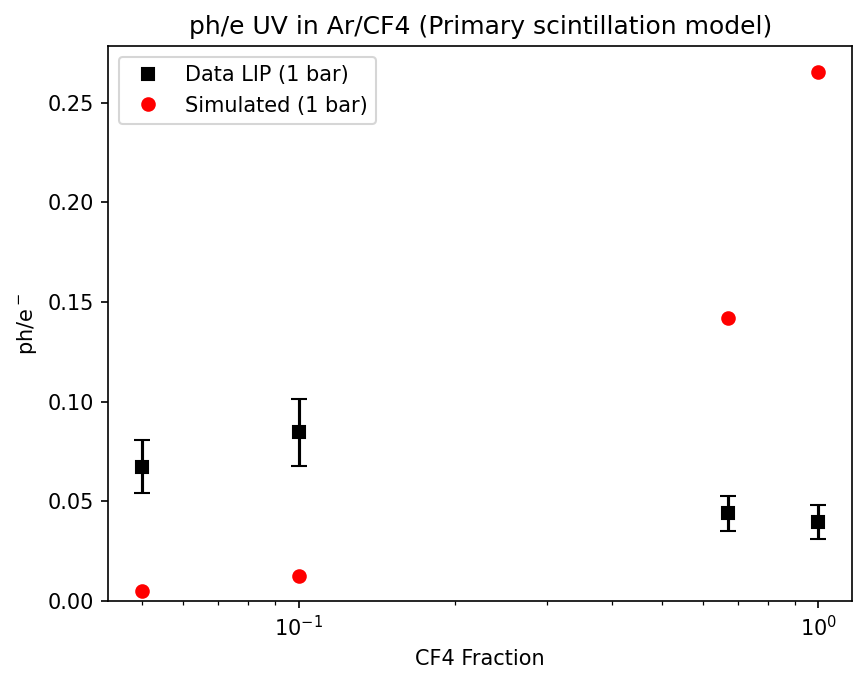

In [14]:
fig_ar_uv_primary, ax_ar_uv_primary = plt.subplots(dpi=150)

list_dic_Ps_to_states = [dic_Ps_to_states_5[0.35], dic_Ps_to_states_10[0.35], dic_Ps_to_states_67[0.35], dic_Ps_to_states_100[0.35]]

for conc_b, ph_e_experimental, error, list_starting_states in zip(ar_cf4_experimental_concs, ar_cf4_experimental_phe_e_uv, ar_cf4_total_errors_uv, list_dic_Ps_to_states):

    n_start_transfer, n_start_dir = list_starting_states

    ph_e_vis, ph_e_uv, ph_i_vis, ph_i_uv, dic_values = ph_e(1, 'ar', 100-conc_b, conc_b, E_fields_ar_cf4[conc_b],
                                                            0.05, 10000, quench_ion=1, n_start_ar=n_start_transfer, n_start_cf4=n_start_dir,
                                                             include_cf3=False, **fit_parameters_wo_uncertainties)
    
    
    
    ax_ar_uv_primary.plot(conc_b / 100, ph_e_uv , 'o', color='r', label=f'Simulated UV {conc_b}% CF4')
    ax_ar_uv_primary.errorbar(conc_b / 100, ph_e_experimental, yerr=error, marker='s', color='k', label=f'Experimental UV {conc_b}% CF4', capsize=4)


ax_ar_uv_primary.set_title('ph/e UV in Ar/CF4 (Primary scintillation model)')

ax_ar_uv_primary.set_xlabel('CF4 Fraction')
ax_ar_uv_primary.set_ylabel('ph/e$^-$')
ax_ar_uv_primary.set_ylim(0)
ax_ar_uv_primary.set_xscale('log')

legend_elements = [


    Line2D([0], [0], marker='s', linestyle='None',
           color='k', markerfacecolor='k', label='Data LIP (1 bar)'),

    Line2D([0], [0], marker='o', linestyle='None',
            color='r', markerfacecolor='r', label='Simulated (1 bar)'),
]


ax_ar_uv_primary.legend(handles=legend_elements)


Text(0.5, 1.0, 'χ$^2$ ph/e uv in Ar/CF4')

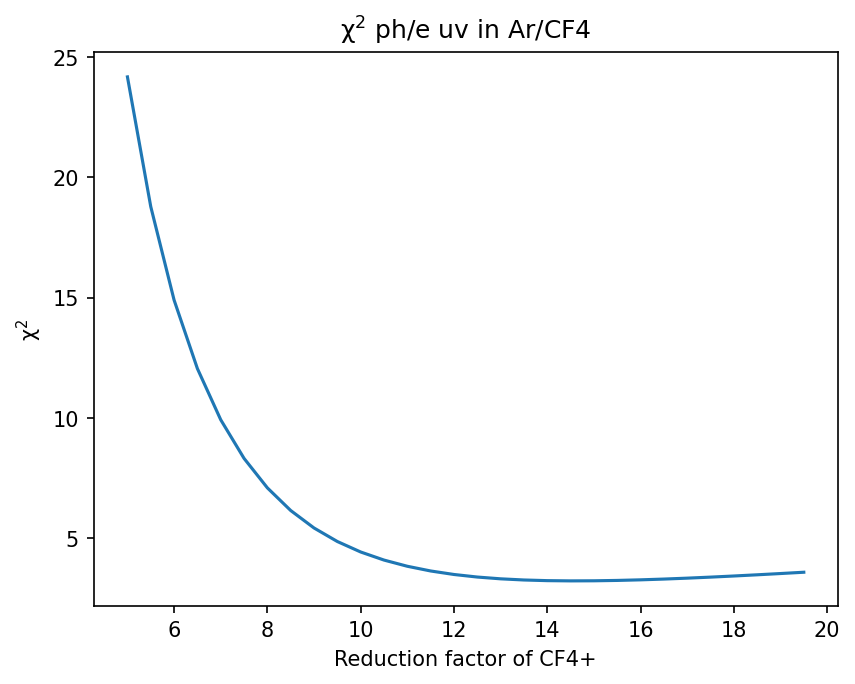

In [15]:
chi2s_list = []

list_dic_Ps_to_states = [dic_Ps_to_states_5[0.35], dic_Ps_to_states_10[0.35], dic_Ps_to_states_67[0.35], dic_Ps_to_states_100[0.35]]


for conc_b, ph_e_experimental, error, list_starting_states in zip(ar_cf4_experimental_concs, ar_cf4_experimental_phe_e_uv, ar_cf4_total_errors_uv, list_dic_Ps_to_states):

    ph_e_vis_array, ph_i_vis_array, ph_e_uv_array, ph_i_uv_array = array_ph_e_uv(5, 20, 0.5, E_fields_ar_cf4[conc_b], 
                                                                                 list_starting_states, 1, 100-conc_b, conc_b, 'ar', 0.05, 10000, **fit_parameters_wo_uncertainties)
    
    chi2_individual = np.array([(ph_e - ph_e_experimental) ** 2 / error ** 2  for ph_e in ph_e_uv_array])
    #print(chi2_individual)
    chi2s_list.append(chi2_individual)



fig_chi2, ax_chi2 = plt.subplots(dpi=150)
#print(chi2s_list)
ax_chi2.plot(np.arange(5, 20, 0.5), sum(chi2s_list))

ax_chi2.set_xlabel('Reduction factor of CF4+')
ax_chi2.set_ylabel('\u03C7$^2$')
ax_chi2.set_title('\u03C7$^2$ ph/e uv in Ar/CF4')

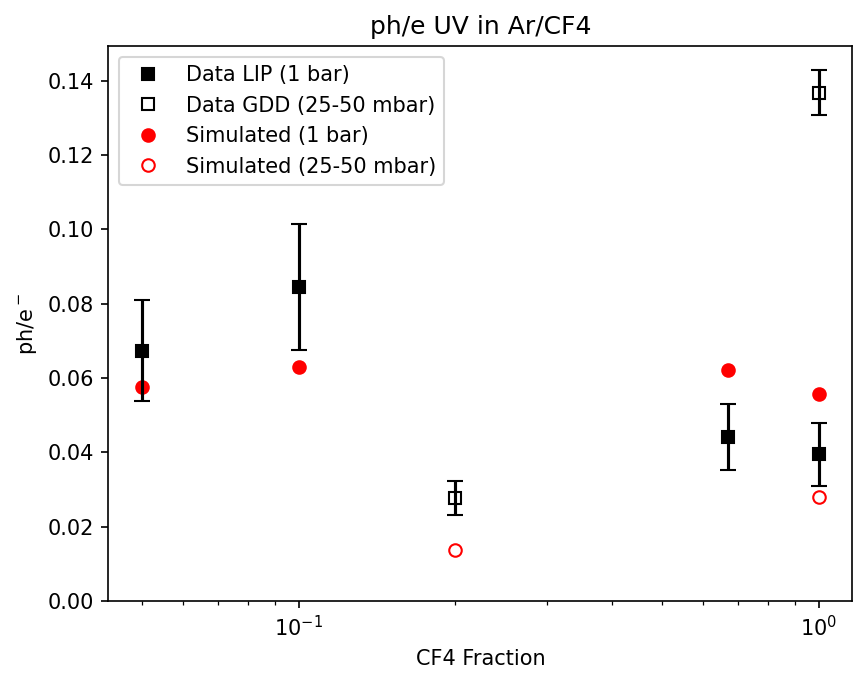

In [16]:
q = 7
fig_ar_uv, ax_ar_uv = plt.subplots(dpi=150)

list_dic_Ps_to_states = [dic_Ps_to_states_5[0.35], dic_Ps_to_states_10[0.35], dic_Ps_to_states_67[0.35], dic_Ps_to_states_100[0.35]]

photons_e_vis = {}
photons_e_uv = {}

for conc_b, ph_e_experimental, error, list_starting_states in zip(ar_cf4_experimental_concs, ar_cf4_experimental_phe_e_uv, ar_cf4_total_errors_uv, list_dic_Ps_to_states):

    n_start_transfer, n_start_dir = list_starting_states

    ph_e_vis, ph_e_uv, ph_i_vis, ph_i_uv, dic_values = ph_e(1, 'ar', 100-conc_b, conc_b, E_fields_ar_cf4[conc_b],
                                                            0.05, 10000, quench_ion=q, n_start_ar=n_start_transfer, n_start_cf4=n_start_dir, **fit_parameters_wo_uncertainties)
    
    photons_e_vis[(conc_b, 1)] = ph_e_vis * 0.35
    photons_e_uv[(conc_b, 1)] = ph_e_uv
    
    ax_ar_uv.plot(conc_b / 100, ph_e_uv , 'o', color='r', label=f'Simulated UV {conc_b}% CF4')
    ax_ar_uv.errorbar(conc_b / 100, ph_e_experimental, yerr=error, marker='s', color='k', label=f'Experimental UV {conc_b}% CF4', capsize=4)
    #print(ph_e_uv)



ph_e_vis, ph_e_uv, ph_i_vis, ph_i_uv, dic_values = ph_e(0.025, 'ar', 0, 100, 10,
                            0.57, 10000, quench_ion=q, n_start_ar=n_start_transfer, n_start_cf4=n_start_dir, **fit_parameters_wo_uncertainties)
photons_e_vis[(100, 0.025)] = ph_e_vis * 0.35
photons_e_uv[(100, 0.025)] = ph_e_uv
ax_ar_uv.plot(1, ph_e_uv , 'ro', markerfacecolor='none', label='Sim UV 100% CF4, 25 mbar')
ax_ar_uv.errorbar(1, yields_cf4_100_25_mbar['uv'], marker='s', color='k', markerfacecolor='none', 
                  yerr= 0.7025875012625137 * ar_cf4_total_errors_uv[-1], label='Exp UV 100% CF4, 25 mbar', capsize=4)


n_start_transfer, n_start_dir = dic_Ps_to_states_20[0.35]
ph_e_vis, ph_e_uv, ph_i_vis, ph_i_uv, dic_values = ph_e(0.05, 'ar', 80, 20, 8.4,
                            0.57, 10000, quench_ion=q, n_start_ar=n_start_transfer, n_start_cf4=n_start_dir, **fit_parameters_wo_uncertainties)
photons_e_vis[(20, 0.05)] = ph_e_vis * 0.35
photons_e_uv[(20, 0.05)] = ph_e_uv
ax_ar_uv.plot(0.2, ph_e_uv, 'ro', label='Sim UV 20% CF4, 50 mbar', markerfacecolor='none',)
ax_ar_uv.errorbar(0.2, yields_arcf4_8020_50_mbar['uv'], marker='s', color='k', markerfacecolor='none', 
                  yerr= 0.5306257209698674 * ar_cf4_total_errors_uv[-1], label='Exp UV 20% CF4, 50 mbar',capsize=4)



# n_start_transfer, n_start_dir = dic_Ps_to_states_20[0.35]
# ph_e_vis, ph_e_uv, ph_i_vis, ph_i_uv, dic_values = ph_e(1, 'ar', 80, 20, 29,
#                             0.57, 10000, quench_ion=q, n_start_ar=n_start_transfer, n_start_cf4=n_start_dir, **fit_parameters_wo_uncertainties)
# photons_e_vis[(20, 1)] = ph_e_vis * 0.35
# photons_e_uv[(20, 1)] = ph_e_uv
# ax_ar_uv.plot(0.2, ph_e_uv, 'ko', label='Sim UV 20% CF4,1 bar')
# ax_ar_uv.errorbar(0.2, yields_arcf4_8020_1_bar['uv'], marker='^', color='k',  
#                   yerr= 1.1668151555772615 * ar_cf4_total_errors_uv[-1], label='Exp UV 20% CF4, 1 bar',capsize=4)

ax_ar_uv.legend()
ax_ar_uv.set_xlabel('CF4 Fraction')
ax_ar_uv.set_ylabel('ph/e$^-$')
ax_ar_uv.set_title('ph/e UV in Ar/CF4')
#ax_ar_uv.set_xlim(0, 105)
ax_ar_uv.set_ylim(0)
ax_ar_uv.set_xscale('log')


legend_elements = [


    Line2D([0], [0], marker='s', linestyle='None',
           color='k', markerfacecolor='k', label='Data LIP (1 bar)'),

    Line2D([0], [0], marker='s', linestyle='None',
           color='k', markerfacecolor='none', label='Data GDD (25-50 mbar)'),
           

    Line2D([0], [0], marker='o', linestyle='None',
            color='r', markerfacecolor='r', label='Simulated (1 bar)'),

    Line2D([0], [0], marker='o', linestyle='None',
           color='r', markerfacecolor='none', label='Simulated (25-50 mbar)')
]


ax_ar_uv.legend(handles=legend_elements)

#plt.text(0.9, 0.12, f'r={q}')

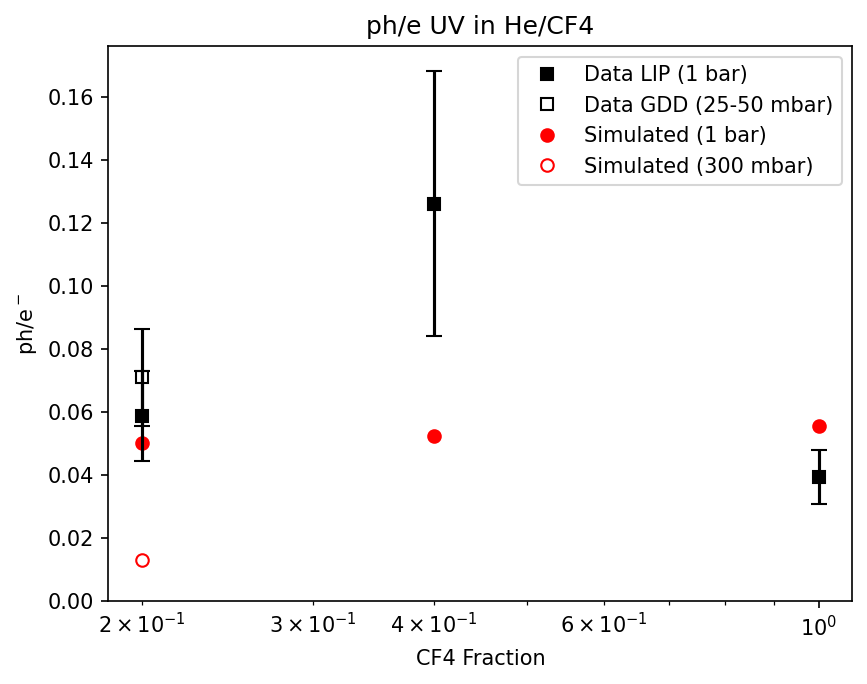

In [17]:
fig_he_uv, ax_he_uv = plt.subplots(dpi=150)

list_dic_Ps_to_states = [dic_Ps_to_states_he_20[0.35], dic_Ps_to_states_he_40[0.35], dic_Ps_to_states_100[0.35]]

photons_e_vis_he = {}
photons_e_uv_he = {}

for conc_b, ph_e_experimental, error in zip(he_cf4_experimental_concs, he_cf4_experimental_phe_e_uv, he_cf4_total_errors_uv):

    n_start_transfer, n_start_dir = list_starting_states

    ph_e_vis, ph_e_uv, ph_i_vis, ph_i_uv, dic_values = ph_e(1, 'he', 100-conc_b, conc_b, E_fields_he_cf4[conc_b],
                                                            0.05, 10000, quench_ion=q, n_start_he=n_start_transfer, n_start_cf4=n_start_dir, **fit_parameters_wo_uncertainties)
    
    photons_e_vis_he[(conc_b, 1)] = ph_e_vis * 0.35
    photons_e_uv_he[(conc_b, 1)] = ph_e_uv

    ax_he_uv.plot(conc_b / 100, ph_e_uv, 'o', color='r', label=f'Simulated UV {conc_b}% CF4')
    ax_he_uv.errorbar(conc_b / 100, ph_e_experimental, marker='s', color='k', yerr=error, label=f'Experimental UV {conc_b}% CF4', capsize=4)


n_start_transfer, n_start_dir = dic_Ps_to_states_he_20[0.35]
ph_e_vis, ph_e_uv, ph_i_vis, ph_i_uv, dic_values = ph_e(0.3, 'he', 80, 20, 12.1,
                            0.57, 10000, quench_ion=q, n_start_he=n_start_transfer, n_start_cf4=n_start_dir, **fit_parameters_wo_uncertainties)
ax_he_uv.plot(0.2, ph_e_uv, 'ro', markerfacecolor='none', label='Sim UV 20% CF4, 300 mbar')
ax_he_uv.errorbar(0.2, yields_hecf4_8020_300_mbar['uv'], marker='s', markerfacecolor='none', color='k', 
                  yerr= 1.8001303441629986 * he_cf4_total_errors_uv[-1], label='Exp UV 20% CF4, 300 mbar',capsize=4)


ax_he_uv.legend()
ax_he_uv.set_xlabel('CF4 Fraction')
ax_he_uv.set_ylabel('ph/e$^-$')
ax_he_uv.set_title('ph/e UV in He/CF4')
#ax_he_uv.set_xlim(0, 105)
ax_he_uv.set_ylim(0)
#ax_he_uv.set_xlim(0)
ax_he_uv.set_xscale('log')


legend_elements = [


    Line2D([0], [0], marker='s', linestyle='None',
           color='k', markerfacecolor='k', label='Data LIP (1 bar)'),

    Line2D([0], [0], marker='s', linestyle='None',
           color='k', markerfacecolor='none', label='Data GDD (25-50 mbar)'),
           

    Line2D([0], [0], marker='o', linestyle='None',
            color='r', markerfacecolor='r', label='Simulated (1 bar)'),

    Line2D([0], [0], marker='o', linestyle='None',
           color='r', markerfacecolor='none', label='Simulated (300 mbar)')
]

ax_he_uv.legend(handles=legend_elements)
#plt.text(0.9, 0.12, f'r={q}')

0.030722713657230845


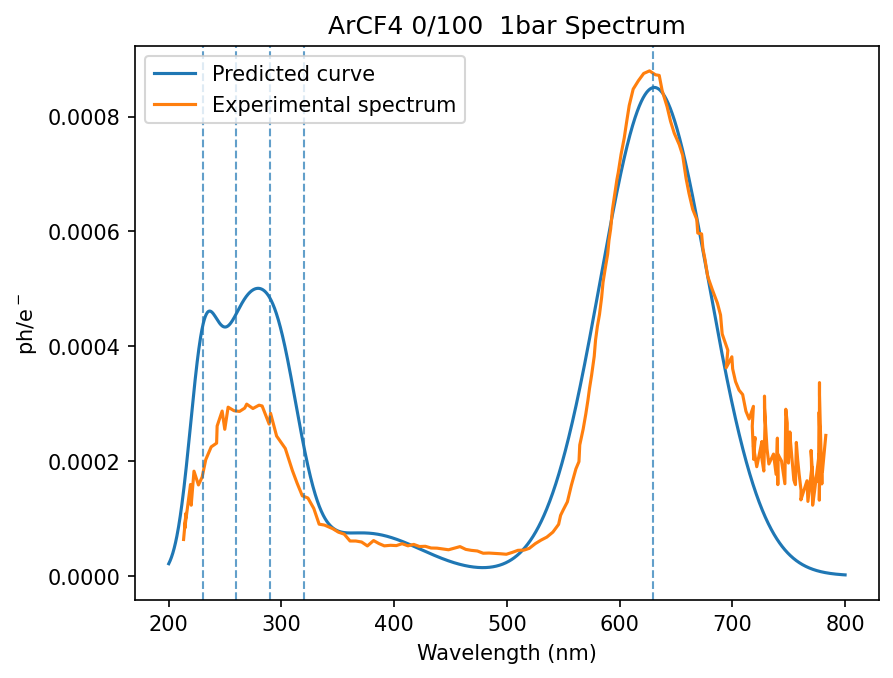

In [18]:
spectrum_generator(1, 'Ar', 100, 'Florian', pars_ref, photons_e_uv[(100, 1)], photons_e_vis[(100, 1)], ar_cf4_experimental_phe_e_uv[-1], ar_cf4_experimental_phe_e_vis[-1])
#plt.text(750, 0.0009, f'r={q}')

0.13653682931656044


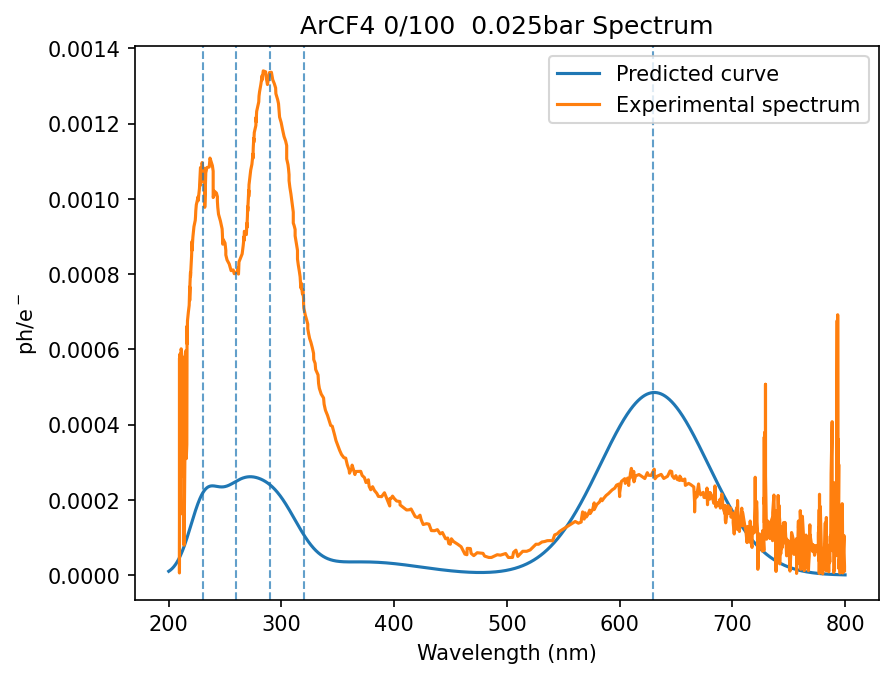

In [19]:
spectrum_generator(0.025, 'Ar', 100, 'Florian', pars_ref, photons_e_uv[(100, 0.025)], photons_e_vis[(100, 0.025)], yields_cf4_100_25_mbar['uv'], yields_cf4_100_25_mbar['vis'])
#plt.text(750, 0.0009, f'r={q}')


0.020030266669402094


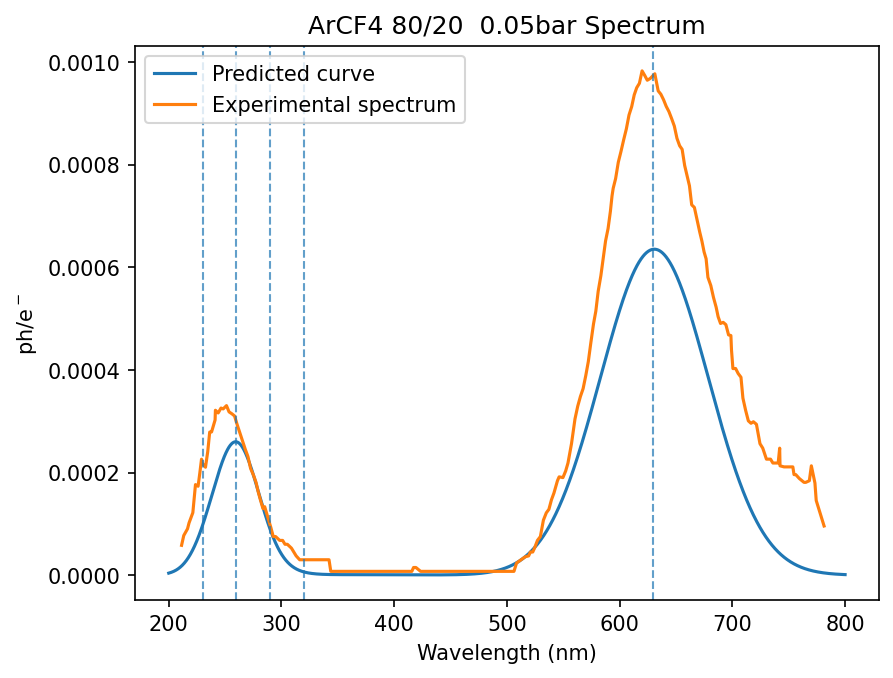

In [20]:
spectrum_generator(0.05, 'Ar', 20, 'Florian', pars_ref, photons_e_uv[(20, 0.05)], photons_e_vis[(20, 0.05)], yields_arcf4_8020_50_mbar['uv'], yields_arcf4_8020_50_mbar['vis'])

0.043999564566285926


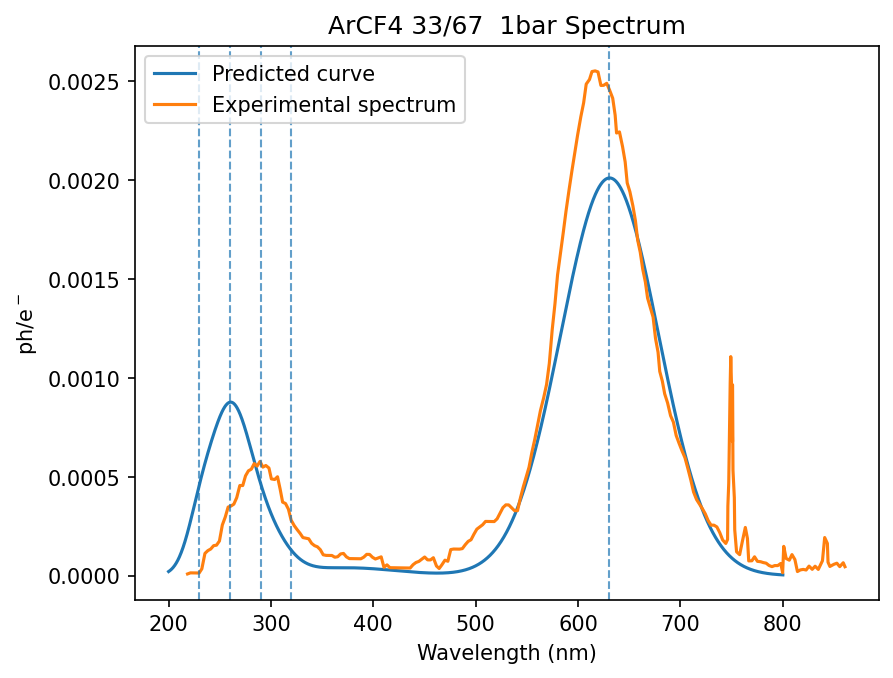

In [21]:
spectrum_generator(1, 'Ar', 67, 'LIP', pars_ref, photons_e_uv[(67, 1)], photons_e_vis[(67, 1)], ar_cf4_experimental_phe_e_uv[2], ar_cf4_experimental_phe_e_vis[2])

0.055045353885159985


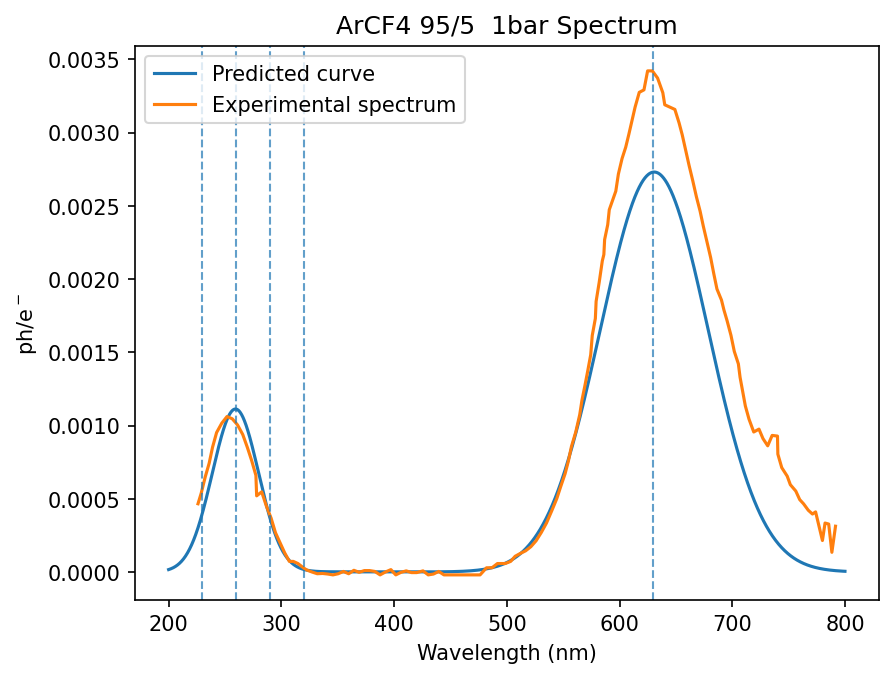

In [22]:
spectrum_generator(1, 'Ar', 5, 'Sara', pars_ref, photons_e_uv[(5, 1)], photons_e_vis[(5, 1)], ar_cf4_experimental_phe_e_uv[0], ar_cf4_experimental_phe_e_vis[0])

0.05211984581207345


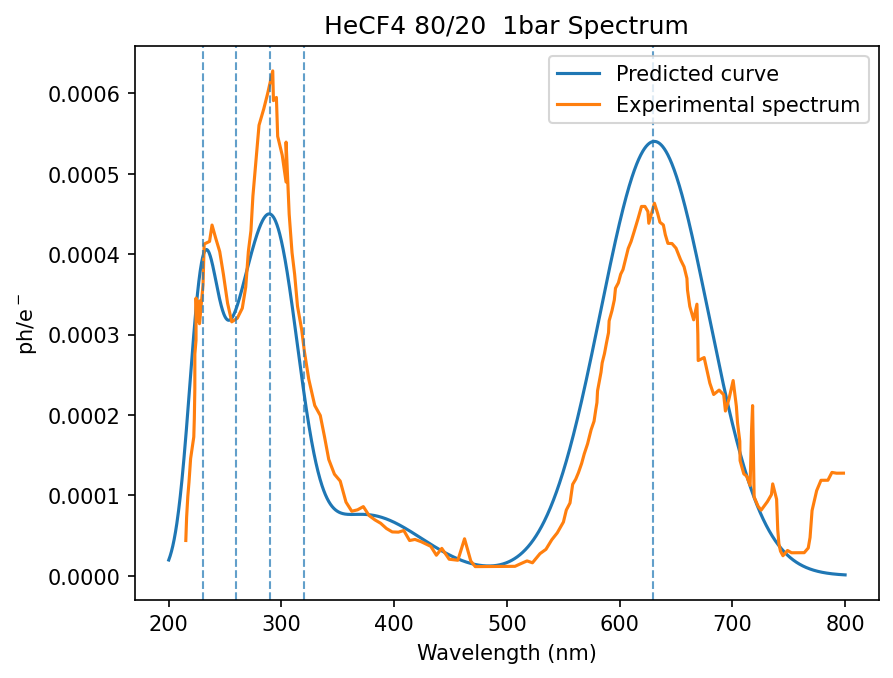

In [23]:
spectrum_generator(1, 'He', 20, 'Florian', pars_ref, photons_e_uv_he[(20, 1)], photons_e_vis_he[(20, 1)], yields_hecf4_8020_300_mbar['uv'], yields_hecf4_8020_300_mbar['vis'])